In [4]:
from vnstock_forecast.builtin.signal_based.interactive import InteractiveSignalSession
from vnstock_forecast.builtin.signal_based.registry import get_all_techniques, get_technique, list_technique_names
from vnstock_forecast.builtin.signal_based.visualization import plot_signal

In [2]:
MACDCrossOver = get_technique("macd_crossover")
SMACrossOver = get_technique("sma_crossover")
SMAShortCrossOver = get_technique("sma_short_crossover")

In [3]:
from datetime import datetime
sma_short_crossover = SMAShortCrossOver()
sma_short_crossover.attach_snapshot = True
session = InteractiveSignalSession()
signals = session.get_signal(
    techniques=[sma_short_crossover],
    symbols=["SHB"],
    from_ts=datetime(2025, 5, 1),
    to_ts=datetime(2026, 3, 18),
)

RSI BUY @ 2025-10-15 — SMA(10)=17585 cắt lên SMA(30)=17577 | gap=0.05% slope=0.716%
  Entry: 18,200  SL: 17,593  TP: 20,020
  R:R = 1:3.00


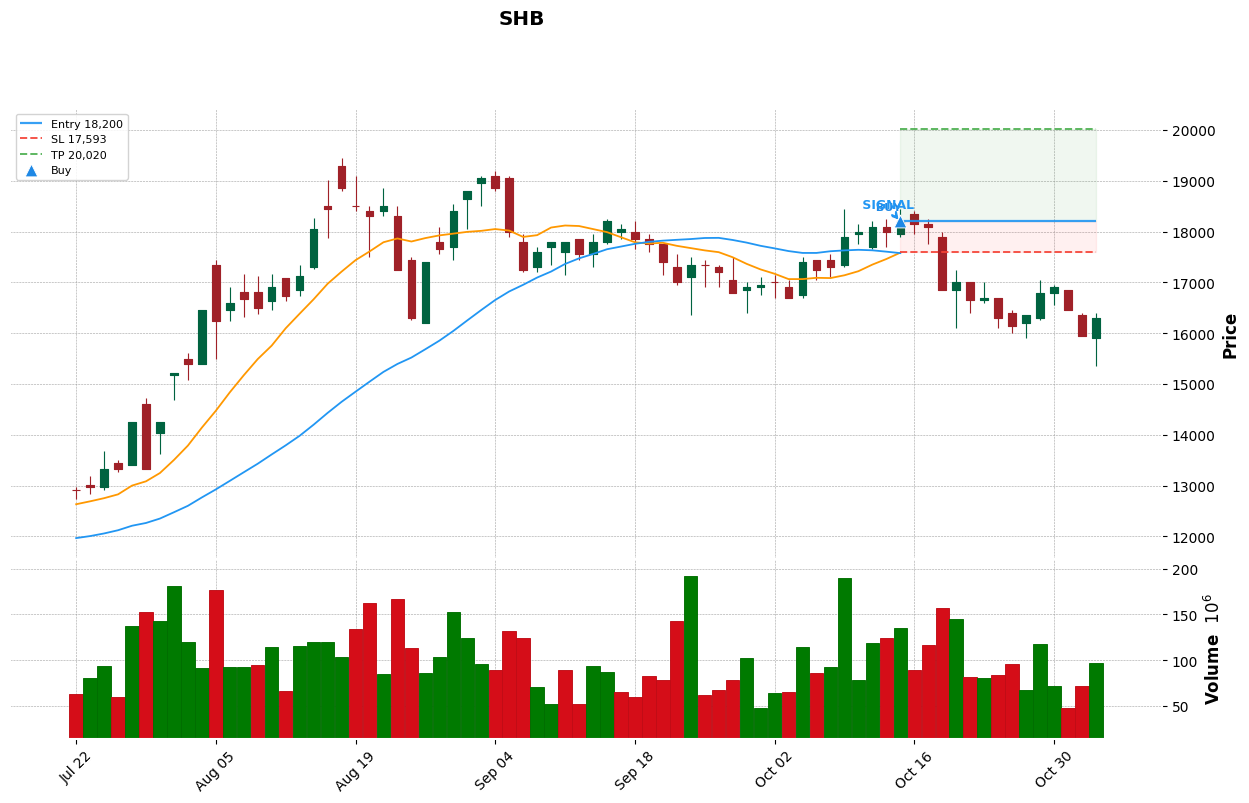

In [12]:
all_signals = [s for s in signals if s.is_buy and s.snapshot]
if all_signals:
    sig = all_signals[1]
    # print(sig.snapshot)
    print(f"RSI BUY @ {sig.timestamp.date()} — {sig.reason}")
    print(f"  Entry: {sig.trade_plan.entry:,.0f}  SL: {sig.trade_plan.stop_loss:,.0f}  TP: {sig.trade_plan.take_profit:,.0f}")
    print(f"  R:R = 1:{sig.trade_plan.rr_ratio():.2f}")
    plot_signal(sig, extend_bars=20, show=True, figsize=(16, 9))
else:
    print("Không có RSI BUY signal nào cho SHB trong khoảng dữ liệu này.")